<a href="https://colab.research.google.com/github/w-b-d/Ml-Project/blob/ACbranch/notebook/final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Breast Cancer Detection**
**Team Members:**  
- Anghel Carrillo  
- Kristopher Church  
- Brianna Magallon  
- William Brady-Diaz  

**Date:** December 2025  


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import glob
import random
import os

import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, Flatten,
    Dense, BatchNormalization, Dropout, GlobalAveragePooling2D)

from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import (train_test_split, GroupShuffleSplit)
from tensorflow.keras.metrics import AUC
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
from sklearn.neighbors import NearestNeighbors

%matplotlib inline


### Intro ###
We will be using the IDC Breast Cancer Dataset to create a model that can predict if a patient has breast cancer based on images of tissues. We will use multiple techniques such as multi processing, CNNs, k nearest neighbors smoothing of models predictions, and Gradcam.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

zip_path = "/content/drive/MyDrive/LeBromide/data/IDC_regular_ps50_idx5.zip"
!unzip -q "$zip_path" -d data/
print("Dataset extracted into /content/data/")

Mounted at /content/drive
Dataset extracted into /content/data/


Number of images found: 277524
Example image: data/IDC_regular_ps50_idx5/12893/1/12893_idx5_x1301_y1901_class1.png


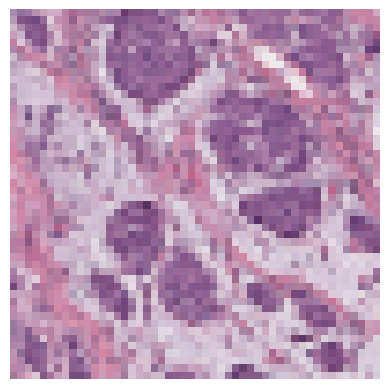

In [6]:
#image_paths = glob.glob("/content/drive/MyDrive/LeBromide/data/unzipped/IDC_regular_ps50_idx5/*/*/*.png")
image_paths = glob.glob("data/IDC_regular_ps50_idx5/*/*/*.png")
print("Number of images found:", len(image_paths))

random_path = random.choice(image_paths)
print("Example image:", random_path)

img = cv2.imread(random_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis("off")
plt.show()

# Baseline Model




In [7]:
data = []
for path in image_paths:
    label = os.path.basename(os.path.dirname(path))
    filename = os.path.basename(path).split('_')
    patient = filename[0]
    x = int(filename[2][1:])
    y = int(filename[3][1:])
    data.append([path, str(label), patient, x, y])

df = pd.DataFrame(data, columns=["filepath", "label", "patient", "x", "y"])

In [9]:

patients = df['patient'].unique()


train_pats, test_pats = train_test_split(
    patients,
    test_size=0.2,
    random_state=42
)


train_df_full = df[df['patient'].isin(train_pats)].reset_index(drop=True)
test_df       = df[df['patient'].isin(test_pats)].reset_index(drop=True)


train_pats2, val_pats = train_test_split(
    train_pats,
    test_size=0.2,
    random_state=42
)

train_df = train_df_full[train_df_full['patient'].isin(train_pats2)].reset_index(drop=True)
val_df   = train_df_full[train_df_full['patient'].isin(val_pats)].reset_index(drop=True)

train_df['label'] = train_df['label'].astype(str)
val_df['label']   = val_df['label'].astype(str)
test_df['label']  = test_df['label'].astype(str)

y_train_numeric = train_df['label'].astype(int).values  # back to ints

classes = np.array([0, 1])
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train_numeric
)
class_weights = {int(c): float(w) for c, w in zip(classes, class_weights_arr)}
print("Class weights:", class_weights)

Class weights: {0: 0.7045795059655948, 1: 1.7220187883435583}


We added werights to the classes as the data set is not balanced, there are lots more negatives compared to positives.

In [10]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

In [11]:
batch_size = 128
target_size = (50, 50)

train_gen = train_datagen.flow_from_dataframe(
    train_df,
    x_col='filepath',
    y_col='label',
    target_size=target_size,
    color_mode='rgb',
    class_mode='binary',
    batch_size=batch_size,
    shuffle=True,
    workers=8,
    use_multiprocessing=True
)

val_gen = val_datagen.flow_from_dataframe(
    val_df,
    x_col='filepath',
    y_col='label',
    target_size=target_size,
    color_mode='rgb',
    class_mode='binary',
    batch_size=batch_size,
    shuffle=False
)

test_gen = test_datagen.flow_from_dataframe(
    test_df,
    x_col='filepath',
    y_col='label',
    target_size=target_size,
    color_mode='rgb',
    class_mode='binary',
    batch_size=batch_size,
    shuffle=False
)

Found 179641 validated image filenames belonging to 2 classes.
Found 46509 validated image filenames belonging to 2 classes.
Found 51374 validated image filenames belonging to 2 classes.


Multi processing training with model creation.

In [12]:
strategy = tf.distribute.MirroredStrategy()

with strategy.scope():
    early_stop = EarlyStopping(monitor='val_loss', patience=5)

    inputs = Input(shape=(50, 50, 3))

    x = Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_uniform',
               padding='same')(inputs)
    x = BatchNormalization()(x)
    x = Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_uniform',
               padding='same')(x)
    x = MaxPooling2D((2, 2))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)


    x = Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_uniform',
               padding='same')(x)
    x = BatchNormalization()(x)
    x = Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_uniform',
               padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)
    x = Dropout(0.3)(x)


    x = Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_uniform',
               padding='same')(x)

    x = GlobalAveragePooling2D()(x)

    x = Dense(64, activation='relu', kernel_initializer='he_uniform')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)

    outputs = Dense(1, activation='sigmoid')(x)

    baseline_model = Model(inputs=inputs, outputs=outputs)

    baseline_model.summary()

    baseline_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', AUC(name='auc')]
    )

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,  # important!
        verbose=1
    )

    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        verbose=1
    )
    EPOCHS = 6

    history = baseline_model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=EPOCHS,
        callbacks=[early_stop, reduce_lr],
        class_weight=class_weights
    )

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 50, 50, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 50, 50, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 50, 50, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 50, 50, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 25, 25, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 25, 25, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 25, 25, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 25, 25, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 25, 25, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 25, 25, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 25, 25, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 148,769 (581.13 KB)

 Trainable params: 148,257 (579.13 KB)

 Non-trainable params: 512 (2.00 KB)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/6
  59/1404 ━━━━━━━━━━━━━━━━━━━━ 53:36 2s/step - accuracy: 0.7390 - auc: 0.8054 - loss: 0.5819

KeyboardInterrupt: 

In [ ]:
print(baseline_model.evaluate(test_gen))

In [ ]:
# data = []

# for path in image_paths:

#     label = os.path.basename(os.path.dirname(path)) # '0' is breast cancer negative, '1' is breast cancer positive
#     filename = os.path.basename(path).split('_')
#     patient = filename[0]
#     x = int(filename[2][1:])
#     y = int(filename[3][1:])
#     data.append([path, str(label), patient, x, y])

# df = pd.DataFrame(data, columns=["filepath", "label", "patient", "x", "y"])

Let's get the class distribution of our dataset. This means knowing how much of the dataset consists of samples that are breast cancer negative and breast cancer positive.

This is important because it informs (1) what a good baseline accuracy is and (2) how severe the data imbalance is.

Regarding (1), if the majority class was 85% of the dataset, then if the model merely only ever predicted the majority class, then the accuracy would be 85% (even though it is mindlessly regurgitating the same answer each time). So in this example, 85% would make a good lower bound for what the accuracy must at least be.

Regarding (2), if there is a significant imbalance (IE: 85% negative, and 15% positive), then this means we need to adopt strategies that minimize the negative effects of data imbalance. For example, it may no longer be reasonable to measure the performance of the model based on accuracy and instead it would be better to use F1 score.

In [ ]:
# GOAL: display the current class distribution in the breast cancer dataset
distributions = df['label'].value_counts(normalize=True)

print(f'Proportion Negative Class: {distributions["0"]:.3f}')
print(f'Proportion Positive Class: {distributions["1"]:.3f}')

Proportion Negative Class: 0.716
Proportion Positive Class: 0.284


In [ ]:
predictions = baseline_model.predict(test_gen).flatten() # These are real numbers within the interval [0,1] and represent the probability of it being cancer positive
targets = test_gen.labels
predicted_classes = (predictions > 0.5).astype(int) # Convert the predicted probabilities into either class '0' or '1'

In [ ]:
def f1_score(preds, targets):
    preds = np.array(preds)
    targets = np.array(targets)

    tp = np.sum(preds * targets)
    fp = np.sum((1 - targets) * preds)
    fn = np.sum(targets * (1 - preds))

    epsilon = 1e-7
    precision = tp / (tp + fp + epsilon)
    recall = tp / (tp + fn + epsilon)
    f1 = 2 * precision * recall / (precision + recall + epsilon)
    return f1

def accuracy(predicted_classes, targets):
    return (predicted_classes == targets).mean()

def test_loss(predictions, targets):
    predictions = np.array(predictions).flatten()
    targets = np.array(targets)
    # Using binary cross entropy loss
    epsilon = 1e-7
    return -np.mean(targets * np.log(predictions + epsilon) + (1 - targets) * np.log(1 - predictions + epsilon))

print("Test F1 Score:", f1_score(predicted_classes, targets))
print("Test Accuracy:", accuracy(predicted_classes, targets))
print("Test Loss:", test_loss(predictions, targets))

Test F1 Score: 0.7886573128850054
Test Accuracy: 0.8675096971699918
Test Loss: 0.3179111205465313


#Grad-CAM Visualization (Beyond Baseline)

After achieving our baseline accuracy, we implemented Grad-CAM to better understand how the model makes predictions. Grad-CAM allows us to visualize which regions of an image contribute most to the model’s decision, providing insight into whether the model is focusing on meaningful tissue structures.


Identify the convolutional layers in the trained baseline model.
Grad-CAM requires the final convolutional layer to generate activation maps.


In [ ]:
for layer in baseline_model.layers:
    if isinstance(layer, tf.keras.layers.Conv2D):
        print(layer.name)

conv2d_10
conv2d_11
conv2d_12
conv2d_13
conv2d_14


Select the final convolutional layer.
This layer contains the highest-level spatial features used by the model.


In [ ]:
last_conv_layer_name = "conv2d_10"


ERROR! Session/line number was not unique in database. History logging moved to new session 51


Define a function to compute the Grad-CAM heatmap.
This function calculates the gradient of the predicted class with respect to the feature maps of the last convolutional layer.


In [ ]:
img_array = np.expand_dims(img, axis=0)  # shape (1, 50, 50, 3)
img_array = img_array.astype("float32") / 255.0  # normalize to [0,1]


def make_gradcam_heatmap(img_array, model, last_conv_layer_name):



    img_tensor = tf.convert_to_tensor(img_array, dtype=tf.float32)

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, preds = grad_model(img_tensor)
        loss = preds[:, 0]  # probability of class 1 (cancer)


    grads = tape.gradient(loss, conv_outputs)


    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))


    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)


    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy()


def display_gradcam(img, heatmap, alpha=0.4):
    """
    Overlay heatmap on original image for visualization.

    Parameters:
    - img: original image, shape (H, W, 3), float32 [0,1]
    - heatmap: Grad-CAM heatmap, shape (H, W), values [0,1]
    - alpha: transparency factor for overlay
    """


    heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))


    heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)


    img_uint8 = np.uint8(img * 255)


    overlay = cv2.addWeighted(img_uint8, 1 - alpha, heatmap_color, alpha, 0)


    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1)
    plt.title("Original")
    plt.imshow(img)
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.title("Grad-CAM")
    plt.imshow(heatmap_resized, cmap="jet")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.title("Overlay")
    plt.imshow(overlay)
    plt.axis("off")

    plt.show()




Select a test image labeled as cancer (label = 1).
This ensures the Grad-CAM visualization is applied to a positive case.


ERROR! Session/line number was not unique in database. History logging moved to new session 52
Prediction probability for cancer: 0.000


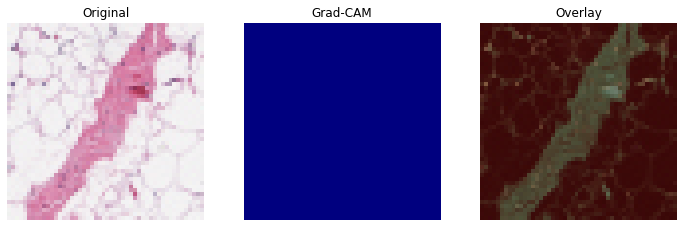

In [ ]:



for imgs, labels in test_gen:
    for i in range(len(labels)):
        if labels[i] == 1:  # cancer
            img = imgs[i].astype("float32") / 255.0  # normalize!
            break
    break


img_array = np.expand_dims(img, axis=0)


pred = baseline_model.predict(img_array)[0][0]
print(f"Prediction probability for cancer: {pred:.3f}")


last_conv_layer_name = "conv2d_10"  # replace with your actual last conv layer
heatmap = make_gradcam_heatmap(img_array, baseline_model, last_conv_layer_name)


display_gradcam(img, heatmap, alpha=0.4)


**Using Neighboring Images to Relable Uncertain Predictions**

Each sample image in the dataset comes from a particular location in the patient's body. in the name of the file, x-y coordinates are given from where the tissue was extracted.

If the model is sufficiently uncertain when predicting the class of a test data sample, then the goal is to look at the predicted classifications for the neighboring tissue samples and use it to inform a more accurate prediction.

In [ ]:
test_df = test_df.merge(
    df[['filepath', 'patient', 'x', 'y']],
    on='filepath',
    how='left'
)
test_df = test_df.reset_index(drop=True)
test_df["prediction"] = predictions
test_df["predicted_class"] = predicted_classes

print(test_df.head(10)) # just making sure it looks good

                                            filepath label patient_id  \
0  C:\Users\samee\Downloads\IDC_regular_ps50_idx5...     0      10259   
1  C:\Users\samee\Downloads\IDC_regular_ps50_idx5...     0      10259   
2  C:\Users\samee\Downloads\IDC_regular_ps50_idx5...     0      10259   
3  C:\Users\samee\Downloads\IDC_regular_ps50_idx5...     0      10259   
4  C:\Users\samee\Downloads\IDC_regular_ps50_idx5...     0      10259   
5  C:\Users\samee\Downloads\IDC_regular_ps50_idx5...     0      10259   
6  C:\Users\samee\Downloads\IDC_regular_ps50_idx5...     0      10259   
7  C:\Users\samee\Downloads\IDC_regular_ps50_idx5...     0      10259   
8  C:\Users\samee\Downloads\IDC_regular_ps50_idx5...     0      10259   
9  C:\Users\samee\Downloads\IDC_regular_ps50_idx5...     0      10259   

   prediction  predicted_class  
0    0.230784                0  
1    0.053567                0  
2    0.105210                0  
3    0.028243                0  
4    0.058059                0 

In [ ]:


# for img_path in test_df['filepath']:
#     # Load and preprocess image
#     img = cv2.imread(img_path)  # or PIL.Image.open
#     img = cv2.resize(img, (50, 50))
#     img = img.astype("float32") / 255.0
#     img_array = np.expand_dims(img, axis=0)

#     pred = baseline_model.predict(img_array)[0][0]  # probability of cancer
#     predictions.append(pred)


test_df['prediction'] = predictions


def smooth_patient_predictions(patient_df, k=5, low=0.45, high=0.55, alpha=0.5):
    n = len(patient_df)
    if n <= 1:
        return patient_df # since there is nothing to smooth

    coordinates = patient_df[['x', 'y']].to_numpy().astype(float)
    predictions = patient_df['prediction'].to_numpy().astype(float)

    # Fit KNN on the tissue samples from this patient
    n_neighbors = min(k + 1, n) # +1 because nearest neighbor is itself
    nbrs = NearestNeighbors(n_neighbors=n_neighbors, algorithm="kd_tree")
    nbrs.fit(coordinates)

    # Find the predictions that are uncertain, and use their neighbors to create a more certain prediction
    mask_uncertain = (predictions >= low) & (predictions <= high)
    index_uncertain = np.where(mask_uncertain)[0]

    for i in index_uncertain:
        distances, indices = nbrs.kneighbors(coordinates[i:i+1], return_distance=True)
        distances = distances[0]
        indices = indices[0]

        # Drop first neighbor since it is just the point itself
        if len(indices) > 1:
            distances = distances[1:]
            indices = indices[1:]
        else:
            continue # no neighbors

        # Distance based weights. Closer neighbors get more influence
        epsilon = 1e-6 # small epsilon is meant to avoid division by zero
        weights = 1.0 / (distances + epsilon)
        weights = weights / weights.sum()
        neighbor_probabilities = predictions[indices]
        neighbor_mean = np.sum(weights * neighbor_probabilities)
        new_probability = (1 - alpha) * predictions[i] + alpha * neighbor_mean
        predictions[i] = new_probability

    smoothed_patient_df = patient_df.copy()
    smoothed_patient_df["prediction"] = predictions
    smoothed_patient_df["predicted_class"] = (smoothed_patient_df["prediction"] >= 0.5).astype(int)

    return smoothed_patient_df

smoothed_dfs = []
for patient, patient_df in test_df.groupby("patient"):
    smoothed = smooth_patient_predictions(
        patient_df, k=5, low=0.45, high=0.55, alpha=0.5
    )
    smoothed_dfs.append(smoothed)

test_df_smoothed = pd.concat(smoothed_dfs).sort_index()


In [ ]:
predicted_classes = test_df_smoothed['predicted_class']
targets = test_df_smoothed['label'].astype(int).to_numpy()
predicted_classes = test_df_smoothed['predicted_class'].astype(int).to_numpy()
predictions = test_df_smoothed['prediction'].to_numpy()

print("Test F1 Score:", f1_score(predicted_classes, targets))
print("Test Accuracy:", accuracy(predicted_classes, targets))
print("Test Loss:", test_loss(predictions, targets))

This approach of using spatial information from neighboring tissue samples slightly improved F1 score and accuracy.

Each tissue sample from a patient includes coordinate information (x, y) indicating where the patch was extracted. For each patient, I plotted their tissue samples in coordinate space and then used a k-nearest-neighbors (KNN) search to identify the neighboring tissue samples to any given sample.

Rather than performing classification with KNN, I used the neighbors’ predicted probabilities to smooth the neural network’s predictions. Specifically, for predictions that were uncertain (between 0.45 and 0.55), I replaced the original probability with a weighted average of its nearest neighbors’ probabilities. After smoothing these uncertain predictions, I re-thresholded them to obtain updated predicted classes.

This spatial smoothing step helped correct some borderline predictions, leading to a modest improvement in overall model performance.

### Conclusion

The model predicts a low probability of cancer for this image.
The Grad-CAM heatmap highlights localized regions rather than the entire image,
indicating that the model is focusing on specific tissue patterns.
This suggests the model is learning meaningful visual features.


Overall our model was able to predict correctly with an accuracy of 86.75%, this shows that we were able to create a model that performs relativly well.

We faced many challenges when working on this project, one being training one epoch took over 26 minutes. We were able to get this time down using multi_processing and adding more workers for training. This helped us to signifigancy reduce our training down to about 3 minutes per epoch. We took inspiration from other high-performing notebooks using this dataset and expanded our model with additional convolution, batch normalization, and pooling layers to strengthen feature extraction. This led us to replace Flatten with GlobalAveragePooling, since Flatten produces an extremely large feature vector that increases the number of parameters and was contributing to overfitting. In contrast, GlobalAveragePooling reduces each feature map to a single value, making the model simpler, better regularized, and less prone to memorizing the training data. We then incorporated class weights to ensure the model treats both classes more evenly despite the imbalance in the dataset, allowing it to learn more effectively from the minority class.

For evaluation, AUC is a more appropriate metric than validation accuracy for our 70/30 imbalanced dataset. Accuracy only reflects performance at a single threshold and can misleadingly reward models that favor the majority class. AUC instead measures how well the model separates the two classes across all thresholds, providing a more reliable and meaningful assessment of the model's true discriminative ability, especially in a medical setting where detecting the minority class is critical.
